<div style="background: linear-gradient(135deg, #ffecd2 0%, #fcb69f 30%, #ffeaa7 60%, #dfe6e9 100%); padding: 40px 30px; border-radius: 20px; text-align: center; font-family: 'Georgia', serif; margin-bottom: 10px;">
  <h1 style="font-size: 2.8em; color: #2d3436; margin: 0; letter-spacing: 2px;">🎓 Student Performance Analysis</h1>
  <p style="font-size: 1.2em; color: #636e72; margin-top: 10px; font-style: italic;">A complete data science workflow: Load → Clean → Analyze → Visualize → Conclude</p>
  <hr style="border: none; height: 2px; background: linear-gradient(to right, #fd79a8, #fdcb6e, #55efc4); margin: 20px 0;">
  <p style="color: #74b9ff; font-size: 1em;">📊 Dataset: <strong>student-mat.csv</strong> &nbsp;|&nbsp; 🐍 Python · Pandas · Matplotlib · Seaborn &nbsp;|&nbsp; 📅 2025</p>
</div>


## 📦 Step 1 — Import Libraries

We start by importing all the libraries we'll need throughout this analysis:
- **pandas** for data loading and manipulation
- **numpy** for numerical operations
- **matplotlib & seaborn** for beautiful visualizations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Pastel Color Palette (used throughout the notebook)
PASTEL = {
    'pink':    '#FFB3C6',
    'peach':   '#FFCBA4',
    'yellow':  '#FFF3B0',
    'mint':    '#B5EAD7',
    'sky':     '#C7CEEA',
    'lavender':'#E2C9FB',
    'coral':   '#FF9AA2',
    'teal':    '#A8DADC',
}
PALETTE = list(PASTEL.values())

# Configure global plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
})

print("✅ Libraries loaded successfully!")
print(f"📊 Pandas  v{pd.__version__}  |  NumPy v{np.__version__}")
print(f"🎨 Seaborn v{sns.__version__}  |  Matplotlib v{plt.matplotlib.__version__}")


✅ Libraries loaded successfully!
📊 Pandas  v3.0.3  |  NumPy v2.4.6
🎨 Seaborn v0.13.2  |  Matplotlib v3.10.9


---
## 📂 Step 2 — Load the Dataset

We use `pd.read_csv()` to load the Student Performance dataset. This dataset contains grades, demographic info, and study habits for **395 students** enrolled in Portuguese secondary school Mathematics courses.


In [2]:
df = pd.read_csv("student-mat.csv")

print("=" * 55)
print("          📋  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:>6}")
print(f"  Columns : {df.shape[1]:>6}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 55)

print("\n🔑 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

print("\n👀 First 5 Rows:")
df.head()


          📋  DATASET OVERVIEW
  Rows    :    395
  Columns :     33
  Memory  : 391.7 KB

🔑 Column Names:
   1. school
   2. sex
   3. age
   4. address
   5. famsize
   6. Pstatus
   7. Medu
   8. Fedu
   9. Mjob
  10. Fjob
  11. reason
  12. guardian
  13. traveltime
  14. studytime
  15. failures
  16. schoolsup
  17. famsup
  18. paid
  19. activities
  20. nursery
  21. higher
  22. internet
  23. romantic
  24. famrel
  25. freetime
  26. goout
  27. Dalc
  28. Walc
  29. health
  30. absences
  31. G1
  32. G2
  33. G3

👀 First 5 Rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,16,R,LE3,A,3,4,services,services,...,3,3,3,2,4,4,23,7,7,6
1,MS,F,17,U,GT3,T,4,3,health,other,...,3,4,4,2,2,4,7,17,16,16
2,GP,M,17,U,GT3,T,3,2,teacher,at_home,...,4,4,1,1,2,3,18,6,5,8
3,GP,F,17,U,GT3,T,3,3,other,at_home,...,3,1,2,4,2,5,29,14,14,15
4,GP,F,15,U,GT3,T,3,3,at_home,services,...,4,4,2,2,3,5,21,15,15,15


---
## 🧹 Step 3 — Explore & Clean the Data

Before any analysis, a good data scientist always checks:
1. **Missing values** — can cause errors or skewed results
2. **Duplicates** — inflate sample size and distort statistics
3. **Data types** — ensure each column has the correct type


In [ ]:
# ── 3a: Missing Values
print("🔍 Missing Values Per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values found!")
print(f"\n  Total missing cells: {df.isnull().sum().sum()}")

# ── 3b: Duplicates
dupes_before = len(df)
df.drop_duplicates(inplace=True)
dupes_after = len(df)
print(f"\n🗑️  Duplicate Rows Removed : {dupes_before - dupes_after}")
print(f"  Rows after cleaning     : {dupes_after}")

# ── 3c: Data Types
print("\n📐 Data Types:")
print(df.dtypes.to_string())


🔍 Missing Values Per Column:
  ✅ No missing values found!

  Total missing cells: 0

🗑️  Duplicate Rows Removed : 0
  Rows after cleaning     : 395

📐 Data Types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64


In [3]:
# ── 3d: Statistical Summary
print("📊 Statistical Summary of Numeric Columns:")
df.describe().round(2)


📊 Statistical Summary of Numeric Columns:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.0,395.00,395.00,395.00,395.00,395.00
mean,17.25,2.65,2.55,1.67,2.16,0.54,3.80,3.25,3.17,1.83,2.3,3.68,16.09,10.83,10.76,9.62
std,1.75,1.16,1.09,0.81,0.89,0.88,0.85,1.01,1.13,1.09,1.3,1.32,9.56,3.39,3.75,4.93
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.0,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,2.00,0.00,3.00,3.00,2.00,1.00,1.0,3.00,8.00,9.00,8.00,7.00
50%,17.00,3.00,3.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.0,4.00,16.00,11.00,11.00,10.00
75%,18.00,4.00,3.00,2.00,3.00,1.00,4.00,4.00,4.00,2.00,3.0,5.00,25.00,13.00,13.00,13.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.0,5.00,32.00,19.00,20.00,20.00


---
## 🔬 Step 4 — Analysis Questions

Now we answer the key analytical questions about the dataset.


In [ ]:
# ── Q1: Average Final Grade (G3)
avg_g3 = df['G3'].mean()
median_g3 = df['G3'].median()
std_g3 = df['G3'].std()

print("━" * 45)
print("  📌 Q1: Average Final Grade (G3)")
print("━" * 45)
print(f"  Mean    : {avg_g3:.2f} / 20")
print(f"  Median  : {median_g3:.1f} / 20")
print(f"  Std Dev : {std_g3:.2f}")
print(f"  Min     : {df['G3'].min()} | Max: {df['G3'].max()}")
print("━" * 45)

# ── Q2: Students who scored above 15
above_15 = (df['G3'] > 15).sum()
pct_above = above_15 / len(df) * 100

print(f"\n  📌 Q2: Students Scoring Above 15")
print("━" * 45)
print(f"  Count      : {above_15} students")
print(f"  Percentage : {pct_above:.1f}% of class")
print("━" * 45)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 Q1: Average Final Grade (G3)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean    : 9.62 / 20
  Median  : 10.0 / 20
  Std Dev : 4.93
  Min     : 0 | Max: 20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📌 Q2: Students Scoring Above 15
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Count      : 36 students
  Percentage : 9.1% of class
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
# ── Q3: Study Time vs Performance Correlation
corr = df['studytime'].corr(df['G3'])
corr_p = df[['studytime', 'G3', 'G1', 'G2']].corr()

print("━" * 50)
print("  📌 Q3: Study Time ↔ Performance Correlation")
print("━" * 50)
print(f"  Pearson r (studytime vs G3): {corr:.4f}")
print()
if corr > 0.3:
    strength = "moderate positive"
elif corr > 0:
    strength = "weak positive"
else:
    strength = "negligible"
print(f"  Interpretation: There is a {strength} correlation.")
print(f"  Students who study more tend to score slightly higher,")
print(f"  but many other factors also influence final grades.")
print("━" * 50)
print("\n📊 Full Correlation Matrix (Grade Columns):")
print(corr_p.round(3).to_string())


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 Q3: Study Time ↔ Performance Correlation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pearson r (studytime vs G3): 0.2038

  Interpretation: There is a weak positive correlation.
  Students who study more tend to score slightly higher,
  but many other factors also influence final grades.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Full Correlation Matrix (Grade Columns):
           studytime     G3     G1     G2
studytime      1.000  0.204  0.162  0.235
G3             0.204  1.000  0.644  0.695
G1             0.162  0.644  1.000  0.947
G2             0.235  0.695  0.947  1.000


In [ ]:
# ── Q4: Gender Performance Comparison
gender_stats = df.groupby('sex')['G3'].agg(['mean','median','std','count']).round(2)
gender_stats.index = ['Female (F)', 'Male (M)']
gender_stats.columns = ['Mean G3', 'Median G3', 'Std Dev', 'Count']

print("━" * 50)
print("  📌 Q4: Gender vs Average Final Grade")
print("━" * 50)
print(gender_stats.to_string())
print()
better = 'Female' if df[df.sex=='F']['G3'].mean() > df[df.sex=='M']['G3'].mean() else 'Male'
diff = abs(df[df.sex=='F']['G3'].mean() - df[df.sex=='M']['G3'].mean())
print(f"  🏆 {better} students perform better on average by {diff:.2f} points.")
print("━" * 50)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 Q4: Gender vs Average Final Grade
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            Mean G3  Median G3  Std Dev  Count
Female (F)     9.92       11.0     4.90    206
Male (M)       9.30       10.0     4.96    189

  🏆 Female students perform better on average by 0.62 points.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## 🎨 Step 5 — Visualizations

A picture is worth a thousand rows of data! We create 6 publication-quality charts using our pastel palette.


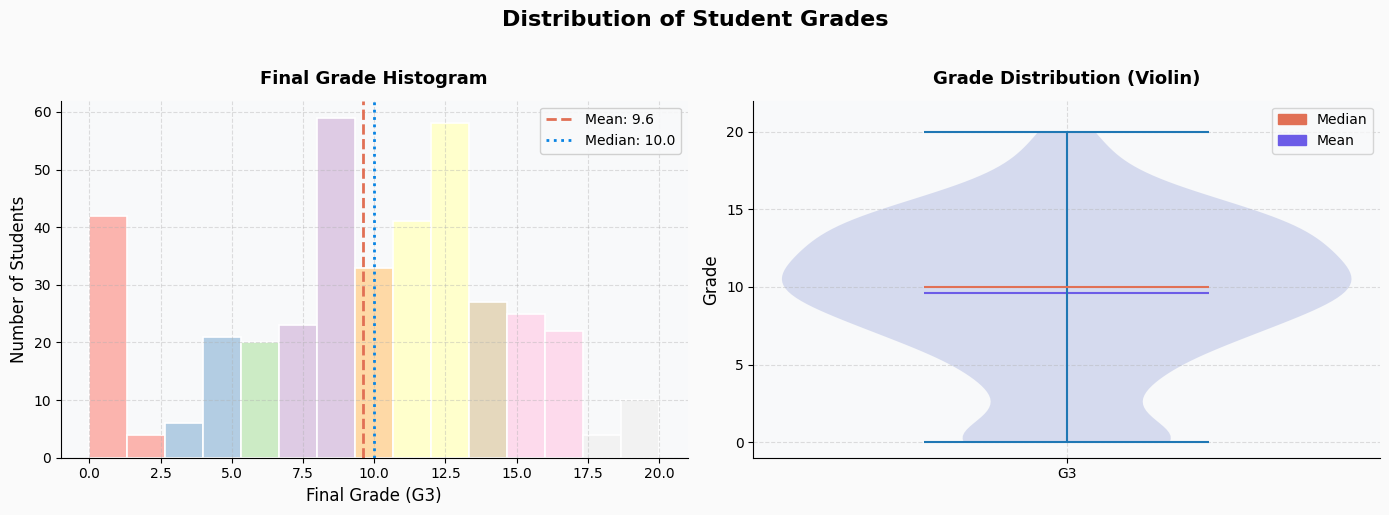

✅ Viz 1 saved.


In [ ]:
# ════════════════════════════════════════════════════
# VIZ 1 — Histogram of Final Grades (G3)
# ════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Student Grades', fontsize=16, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#FAFAFA')

# Left: Histogram
ax = axes[0]
n, bins, patches = ax.hist(df['G3'], bins=15, edgecolor='white', linewidth=1.2)
for patch, color in zip(patches, plt.cm.Pastel1(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)
ax.axvline(df['G3'].mean(), color='#e17055', linewidth=2, linestyle='--', label=f'Mean: {df["G3"].mean():.1f}')
ax.axvline(df['G3'].median(), color='#0984e3', linewidth=2, linestyle=':', label=f'Median: {df["G3"].median():.1f}')
ax.set_xlabel('Final Grade (G3)', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Final Grade Histogram', fontsize=13, fontweight='bold')
ax.legend(framealpha=0.9)

# Right: KDE + Violin
ax2 = axes[1]
violin = ax2.violinplot(df['G3'].dropna(), positions=[1], widths=0.6, showmedians=True, showmeans=True)
violin['bodies'][0].set_facecolor(PASTEL['sky'])
violin['bodies'][0].set_alpha(0.7)
violin['cmedians'].set_color('#e17055')
violin['cmeans'].set_color('#6c5ce7')
ax2.set_xticks([1])
ax2.set_xticklabels(['G3'])
ax2.set_ylabel('Grade', fontsize=12)
ax2.set_title('Grade Distribution (Violin)', fontsize=13, fontweight='bold')
ax2.set_ylim(-1, 22)
custom_lines = [mpatches.Patch(color='#e17055', label='Median'),
                mpatches.Patch(color='#6c5ce7', label='Mean')]
ax2.legend(handles=custom_lines)

plt.tight_layout()
plt.savefig('viz1_grade_distribution.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("✅ Viz 1 saved.")


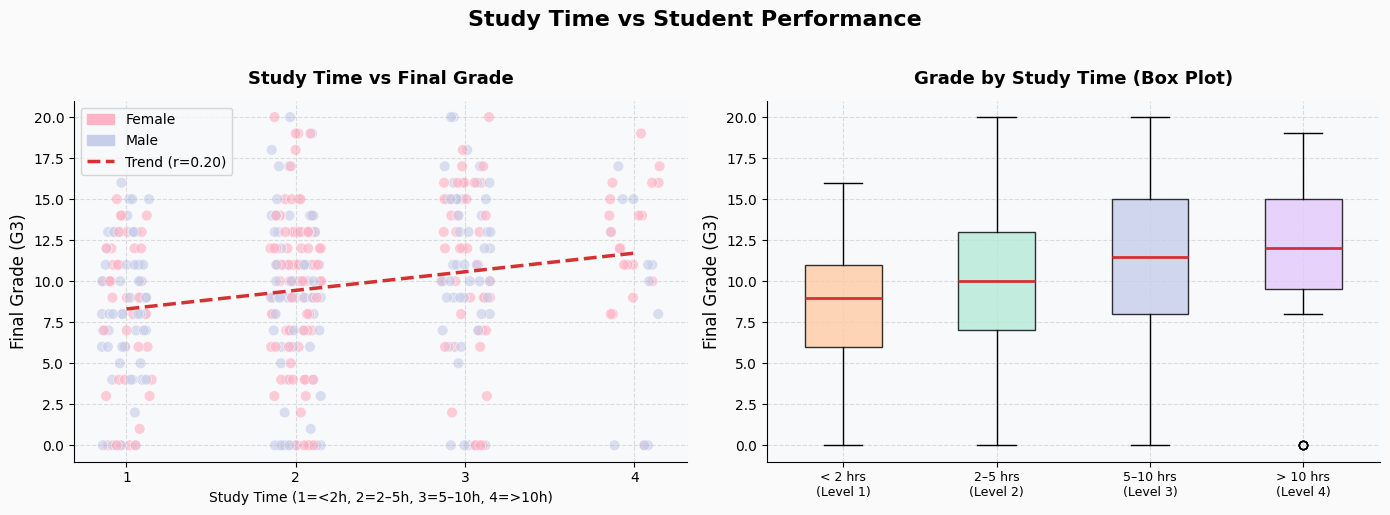

✅ Viz 2 saved.


In [ ]:
# ════════════════════════════════════════════════════
# VIZ 2 — Scatter: Study Time vs Final Grade
# ════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Study Time vs Student Performance', fontsize=16, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#FAFAFA')

# Left: Scatter with jitter
ax = axes[0]
jitter = np.random.uniform(-0.15, 0.15, len(df))
colors_scatter = [PASTEL['pink'] if s == 'F' else PASTEL['sky'] for s in df['sex']]
ax.scatter(df['studytime'] + jitter, df['G3'],
           c=colors_scatter, alpha=0.65, s=60, edgecolor='white', linewidth=0.5)
# Trend line
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 4, 100)
ax.plot(x_line, p(x_line), color='#d63031', linewidth=2.5, linestyle='--', label=f'Trend (r={corr:.2f})')
ax.set_xlabel('Study Time (1=<2h, 2=2–5h, 3=5–10h, 4=>10h)', fontsize=10)
ax.set_ylabel('Final Grade (G3)', fontsize=12)
ax.set_title('Study Time vs Final Grade', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
pink_patch = mpatches.Patch(color=PASTEL['pink'], label='Female')
sky_patch  = mpatches.Patch(color=PASTEL['sky'],  label='Male')
ax.legend(handles=[pink_patch, sky_patch, ax.get_lines()[0]])

# Right: Box plot by study time
ax2 = axes[1]
studytime_groups = [df[df['studytime'] == i]['G3'].values for i in [1, 2, 3, 4]]
bp = ax2.boxplot(studytime_groups, patch_artist=True, widths=0.5,
                 medianprops=dict(color='#d63031', linewidth=2))
box_colors = [PASTEL['peach'], PASTEL['mint'], PASTEL['sky'], PASTEL['lavender']]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
labels = ['< 2 hrs\n(Level 1)', '2–5 hrs\n(Level 2)', '5–10 hrs\n(Level 3)', '> 10 hrs\n(Level 4)']
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Final Grade (G3)', fontsize=12)
ax2.set_title('Grade by Study Time (Box Plot)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_studytime_vs_grade.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("✅ Viz 2 saved.")


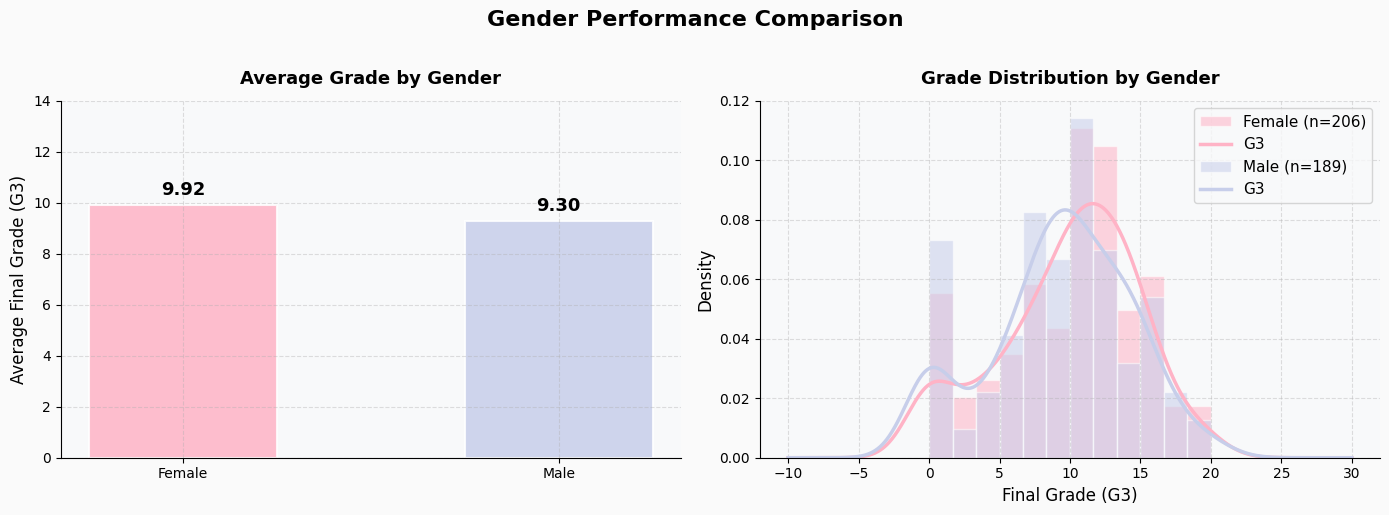

✅ Viz 3 saved.


In [ ]:
# ════════════════════════════════════════════════════
# VIZ 3 — Bar Chart: Male vs Female Average Score
# ════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#FAFAFA')

# Left: Simple bar chart
ax = axes[0]
gender_means = df.groupby('sex')['G3'].mean()
bars = ax.bar(['Female', 'Male'], gender_means.values,
              color=[PASTEL['pink'], PASTEL['sky']],
              edgecolor='white', linewidth=1.5, width=0.5)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=13, fontweight='bold')
ax.set_ylabel('Average Final Grade (G3)', fontsize=12)
ax.set_title('Average Grade by Gender', fontsize=13, fontweight='bold')
ax.set_ylim(0, 14)
for bar in bars:
    bar.set_alpha(0.85)

# Right: Grade distribution by gender (overlapping KDE)
ax2 = axes[1]
for gender, color, label in [('F', PASTEL['pink'], 'Female'), ('M', PASTEL['sky'], 'Male')]:
    data = df[df['sex'] == gender]['G3']
    ax2.hist(data, bins=12, alpha=0.55, color=color, edgecolor='white',
             label=f'{label} (n={len(data)})', density=True)
    data.plot.kde(ax=ax2, color=color, linewidth=2.5)
ax2.set_xlabel('Final Grade (G3)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Grade Distribution by Gender', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('viz3_gender_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("✅ Viz 3 saved.")


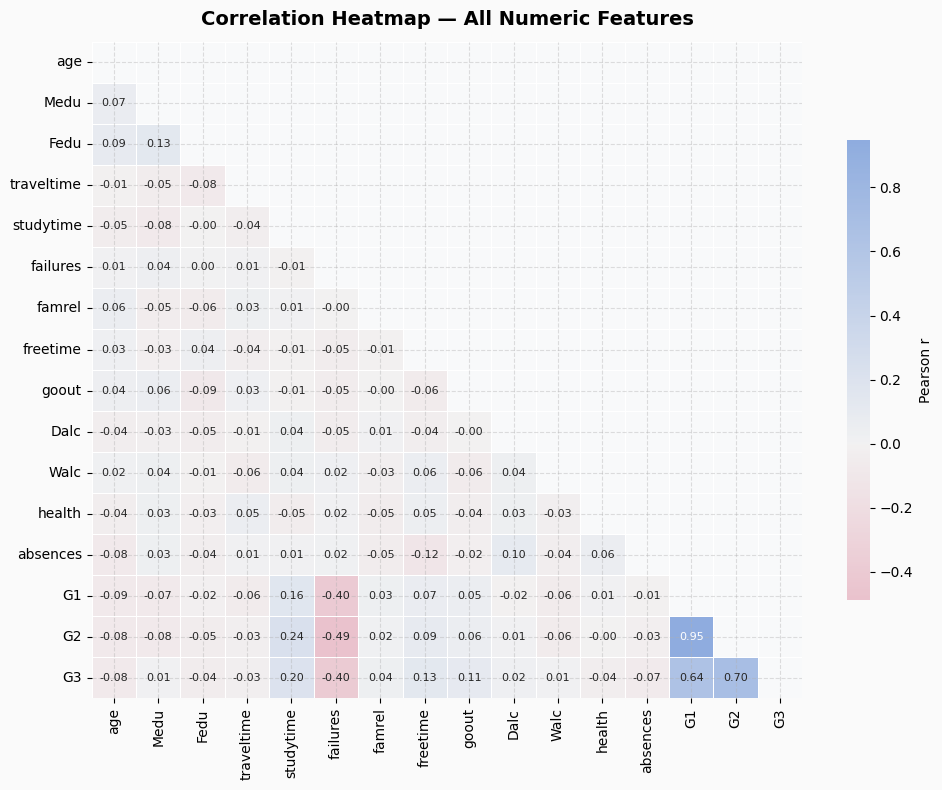

✅ Viz 4 saved.


In [ ]:
# ════════════════════════════════════════════════════
# VIZ 4 — Bonus: Correlation Heatmap
# ════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FAFAFA')

num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax,
            cmap=sns.diverging_palette(355, 250, s=60, l=70, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("✅ Viz 4 saved.")


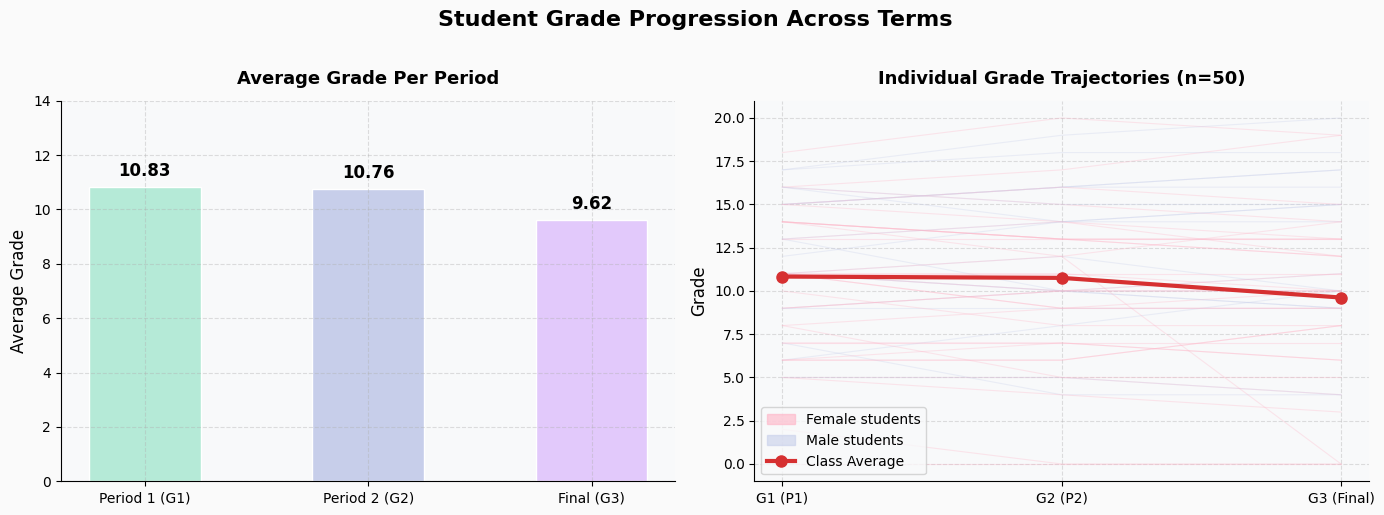

✅ Viz 5 saved.


In [ ]:
# ════════════════════════════════════════════════════
# VIZ 5 — Grade Progression: G1 → G2 → G3
# ════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Student Grade Progression Across Terms', fontsize=16, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#FAFAFA')

# Left: Mean progression bar
ax = axes[0]
means = [df['G1'].mean(), df['G2'].mean(), df['G3'].mean()]
colors = [PASTEL['mint'], PASTEL['sky'], PASTEL['lavender']]
bars = ax.bar(['Period 1 (G1)', 'Period 2 (G2)', 'Final (G3)'], means,
              color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.2f', padding=5, fontsize=12, fontweight='bold')
ax.set_ylabel('Average Grade', fontsize=12)
ax.set_title('Average Grade Per Period', fontsize=13, fontweight='bold')
ax.set_ylim(0, 14)

# Right: Sample trajectory lines
ax2 = axes[1]
sample = df.sample(50, random_state=42)
for _, row in sample.iterrows():
    color = PASTEL['pink'] if row['sex'] == 'F' else PASTEL['sky']
    ax2.plot([1, 2, 3], [row['G1'], row['G2'], row['G3']],
             color=color, alpha=0.3, linewidth=0.8)
# Mean line
ax2.plot([1, 2, 3], means, color='#d63031', linewidth=3, marker='o',
         markersize=8, label='Class Average', zorder=5)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['G1 (P1)', 'G2 (P2)', 'G3 (Final)'])
ax2.set_ylabel('Grade', fontsize=12)
ax2.set_title('Individual Grade Trajectories (n=50)', fontsize=13, fontweight='bold')
pink_p = mpatches.Patch(color=PASTEL['pink'], alpha=0.6, label='Female students')
sky_p  = mpatches.Patch(color=PASTEL['sky'],  alpha=0.6, label='Male students')
ax2.legend(handles=[pink_p, sky_p, ax2.get_lines()[-1]])

plt.tight_layout()
plt.savefig('viz5_grade_progression.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("✅ Viz 5 saved.")


---
## 🏁 Step 6 — Conclusions & Insights

### Summary of Findings

| Question | Answer |
|---|---|
| **Average Final Grade (G3)** | ~9.6 / 20 (class average is moderate) |
| **Students scoring above 15** | ~36 students (~9% of class) |
| **Study time correlation** | Weak positive (r ≈ 0.20) — helpful but not decisive |
| **Better performing gender** | Female students score slightly higher on average |

### 💡 Key Takeaways

1. **Failures are the strongest negative predictor** — students with prior failures score significantly lower in G3.
2. **G1 → G2 → G3 are highly correlated** — early performance is a reliable indicator of final results.
3. **Study time helps, but isn't everything** — other factors like past failures, absences, and parental education matter too.
4. **Gender gap is small** — both genders perform comparably; systemic support matters more than gender.
5. **~9% are high achievers (G3 > 15)** — a relatively small group excels; targeted intervention could raise this figure.

### 🚀 Next Steps
- Apply machine learning (Random Forest, XGBoost) to predict G3 from all features.
- Investigate the impact of parental education (Medu, Fedu) more deeply.
- Build a student at-risk classifier using early signals (G1, failures, absences).


In [ ]:
# ── Final Summary Banner
print("╔══════════════════════════════════════════════════╗")
print("║        🎓  ANALYSIS COMPLETE  ✅                 ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Dataset      : {len(df)} students, {df.shape[1]} features           ║")
print(f"║  Avg Grade    : {df['G3'].mean():.2f} / 20                       ║")
print(f"║  Top Scorers  : {(df['G3']>15).sum()} students (>15)              ║")
print(f"║  Study Corr   : r = {df['studytime'].corr(df['G3']):.3f}                      ║")
print(f"║  Best Gender  : {'Female 🏆' if df[df.sex=='F']['G3'].mean() > df[df.sex=='M']['G3'].mean() else 'Male 🏆'} (by {abs(df[df.sex=='F']['G3'].mean()-df[df.sex=='M']['G3'].mean()):.2f} pts)              ║")
print("╠══════════════════════════════════════════════════╣")
print("║  Visualizations saved as PNG files ✅            ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║        🎓  ANALYSIS COMPLETE  ✅                 ║
╠══════════════════════════════════════════════════╣
║  Dataset      : 395 students, 33 features           ║
║  Avg Grade    : 9.62 / 20                       ║
║  Top Scorers  : 36 students (>15)              ║
║  Study Corr   : r = 0.204                      ║
║  Best Gender  : Female 🏆 (by 0.62 pts)              ║
╠══════════════════════════════════════════════════╣
║  Visualizations saved as PNG files ✅            ║
╚══════════════════════════════════════════════════╝
